# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [42]:
%pip install pandas numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [43]:
# === STANDALONE LAST SPIKE DETECTOR ===

import pandas as pd
import numpy as np
import requests
from typing import Optional, Dict, Tuple
import warnings

warnings.filterwarnings("ignore")

symbol = "API3USDC"


class SpikeHunter:
    """Production spike detection system for cryptocurrency assets.

    Adds two-stage signaling:
    - early_signal: potential emerging spike (softer conditions / breakout / acceleration)
    - spike_signal: confirmed spike (original stricter logic)
    """

    def __init__(
        self,
        price_threshold=0.020,
        volume_threshold=2.0,
        momentum_threshold=0.015,
        window=12,
        rsi_oversold=30,
        early_price_frac: float = 0.7,  # stricter
        early_volume_frac: float = 0.8, # stricter
        early_lookback: int = 3,
        breakout_buffer: float = 0.002,
        early_momentum_frac: float = 0.7, # stricter
        confirm_window: int = 3, # new: allow confirmation within N candles after early
    ):
        self.price_threshold = price_threshold
        self.volume_threshold = volume_threshold
        self.momentum_threshold = momentum_threshold
        self.window = window
        self.rsi_oversold = rsi_oversold
        self.early_price_frac = early_price_frac
        self.early_volume_frac = early_volume_frac
        self.early_lookback = early_lookback
        self.breakout_buffer = breakout_buffer
        self.early_momentum_frac = early_momentum_frac
        self.confirm_window = confirm_window

    def fetch_binance_klines(symbol="IDEXUSDC", interval="15m", limit=500, end_time=None):
        url = "https://api.binance.com/api/v3/klines"
        params = {"symbol": symbol, "interval": interval, "limit": limit}
        if end_time:
            params["endTime"] = end_time
        resp = requests.get(url, params=params)
        data = resp.json()
        df = pd.DataFrame(
            data,
            columns=[
                "open_time",
                "open",
                "high",
                "low",
                "close",
                "volume",
                "close_time",
                "qav",
                "num_trades",
                "taker_base",
                "taker_quote",
                "ignore",
            ],
        )
        df = df[["open_time", "open", "high", "low", "close", "volume"]].astype(float)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        df = df.sort_values("timestamp").reset_index(drop=True)
        return df

    # --- Step 2: Fetch ADR data ---
    def fetch_adr_series(size=500):
        url = f"https://api.terminal.binbot.in/charts/adr-series?size={size}"
        resp = requests.get(url)
        j = resp.json()
        df_adr = pd.DataFrame(
            {
                "timestamp": pd.to_datetime(j["data"]["timestamp"]),
                "adp_ma": j["data"]["adp_ma"],
                "advancers": j["data"]["advancers"],
                "decliners": j["data"]["decliners"],
                "adp": j["data"]["adp"],
                "total_volume": j["data"]["total_volume"],
            }
        )
        return df_adr

    def fetch_market_data(
        self,
        symbol: str,
        interval: str = "15m",
        limit: int = 500,
        end_time: Optional[int] = None,
    ) -> pd.DataFrame:
        """Fetch candlestick data from Binance API."""
        try:
            url = "https://api.binance.com/api/v3/klines"
            params = {"symbol": symbol, "interval": interval, "limit": limit}
            if end_time:
                params["endTime"] = end_time

            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()

            df = pd.DataFrame(
                data,
                columns=[
                    "open_time",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "close_time",
                    "qav",
                    "num_trades",
                    "taker_base",
                    "taker_quote",
                    "ignore",
                ],
            )

            # Convert to proper types
            numeric_cols = ["open", "high", "low", "close", "volume"]
            df[numeric_cols] = df[numeric_cols].astype(float)
            df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")

            # Keep only essential columns
            df = df[["timestamp", "open", "high", "low", "close", "volume"]]
            return df.sort_values("timestamp").reset_index(drop=True)

        except Exception as e:
            raise Exception(f"Failed to fetch market data for {symbol}: {str(e)}")

    def calculate_rsi(self, prices: pd.Series, window: int = 14) -> pd.Series:
        """Calculate RSI indicator efficiently."""
        delta = prices.diff()
        gain = delta.where(delta > 0, 0).rolling(window=window, min_periods=1).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window, min_periods=1).mean()
        rs = gain / (loss + 1e-10)
        return 100 - (100 / (1 + rs))

    def detect_spikes(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # Basic calculations
        df["price_change"] = df["close"].pct_change()
        df["body_size"] = abs(df["close"] - df["open"])
        df["body_size_pct"] = df["body_size"] / df["open"]

        # Volume analysis with adaptive window
        effective_window = min(self.window, len(df) // 4)
        if effective_window < 3:
            effective_window = 3

        df["volume_ma"] = (
            df["volume"].rolling(window=effective_window, min_periods=1).mean()
        )
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-10)

        # Rolling highs for breakout precondition
        df["rolling_high"] = df["high"].rolling(self.window, min_periods=2).max()

        # RSI calculation
        df["rsi"] = self.calculate_rsi(df["close"])

        # Momentum aggregates
        df["cum_price_change_3"] = df["price_change"].rolling(3).sum()
        df["cum_price_change_early"] = df["price_change"].rolling(self.early_lookback).sum()
        df["volume_ratio_change"] = df["volume_ratio"].diff()

        # Initialize signals
        df["early_signal"] = 0
        df["early_reason"] = ""
        df["spike_signal"] = 0
        df["spike_type"] = ""
        df["signal_strength"] = 0.0
        df["lead_time_candles"] = np.nan  # how many candles between early and confirmed

        last_early_idx = None
        early_pending = []  # store (idx, reason) for windowed confirmation

        for i in range(effective_window, len(df)):
            current_price_change = df.loc[i, "price_change"]
            current_volume_ratio = df.loc[i, "volume_ratio"]
            current_rsi = df.loc[i, "rsi"]

            # ---------- CONFIRMED SPIKE LOGIC ----------
            signal = 0
            signal_type = ""
            strength = 0.0

            if (
                current_price_change > self.price_threshold
                and current_volume_ratio > self.volume_threshold
            ):
                signal = 1
                signal_type = "price_volume"
                strength = min(current_price_change * current_volume_ratio * 10, 10.0)
            elif i >= 5:
                recent_changes = df.loc[i - 3 : i, "price_change"]
                positive_moves = (recent_changes > self.momentum_threshold).sum()
                total_momentum = recent_changes.sum()
                if positive_moves >= 2 and total_momentum > self.price_threshold:
                    signal = 1
                    signal_type = "momentum"
                    strength = min(total_momentum * 20, 8.0)
            elif (
                i >= 14
                and current_rsi > self.rsi_oversold
                and df.loc[i - 1, "rsi"] <= self.rsi_oversold
                and current_price_change > 0.008
            ):
                signal = 1
                signal_type = "rsi_reversal"
                strength = min(
                    (current_rsi - self.rsi_oversold) / 10 * current_price_change * 50,
                    6.0,
                )

            # Only look for an early signal if we did NOT confirm on this candle
            if signal == 0 and i >= self.early_lookback:
                cond_a = (
                    current_price_change > self.price_threshold * self.early_price_frac
                    and current_volume_ratio > self.volume_threshold * self.early_volume_frac
                    and (df.loc[i - 1, "price_change"] > 0 or df.loc[i - 2, "price_change"] > 0)
                )
                cond_b = (
                    df.loc[i, "close"]
                    > (df.loc[i, "rolling_high"] * (1 + self.breakout_buffer))
                    and current_volume_ratio > 1.2
                )
                cond_c = (
                    df.loc[i, "cum_price_change_early"]
                    > self.price_threshold * self.early_momentum_frac
                    and df.loc[i - 1, "volume_ratio_change"] > 0
                    and current_volume_ratio > 1.0
                )
                if cond_a or cond_b or cond_c:
                    if cond_a:
                        reason = "partial_threshold"
                    elif cond_b:
                        reason = "breakout"
                    else:
                        reason = "cumulative_momentum"
                    df.loc[i, "early_signal"] = 1
                    df.loc[i, "early_reason"] = reason
                    early_pending.append((i, reason))

            # Windowed confirmation: if a confirmed spike occurs, check for any early within window
            if signal == 1 and early_pending:
                # Find the most recent early within window
                for idx, reason in reversed(early_pending):
                    if 0 < i - idx <= self.confirm_window:
                        df.loc[i, "lead_time_candles"] = i - idx
                        early_pending = [ep for ep in early_pending if ep[0] > i - self.confirm_window]  # keep only recent
                        break

            df.loc[i, "spike_signal"] = signal
            df.loc[i, "spike_type"] = signal_type
            df.loc[i, "signal_strength"] = strength

        return df

    def run_analysis(
        self, symbol: str, interval: str = "15m", limit: int = 500, verbose: bool = True
    ) -> Tuple[pd.DataFrame, Dict]:
        """Run complete spike analysis for a trading pair."""
        df = self.fetch_market_data(symbol, interval, limit)
        df = self.detect_spikes(df)
        spikes = df[df["spike_signal"] == 1]
        early = df[df["early_signal"] == 1]
        lead_times = df.loc[df["lead_time_candles"].notna(), "lead_time_candles"]
        summary = {
            "total_spikes": int(len(spikes)),
            "total_early": int(len(early)),
            "median_lead_candles": float(lead_times.median()) if len(lead_times) else None,
            "spike_rate": len(spikes) / len(df) if len(df) > 0 else 0,
            "early_rate": len(early) / len(df) if len(df) > 0 else 0,
            "date_range": f"{df['timestamp'].min()} to {df['timestamp'].max()}",
        }
        return df, summary

    def get_last_spike_details(self, df, symbol="CFXUSDC", max_minutes_ago=30):
        spikes = df[df["spike_signal"] == 1]
        if len(spikes) == 0:
            return None
        last_spike = spikes.iloc[-1]
        current_time = pd.Timestamp.now(tz="UTC")
        spike_time = last_spike["timestamp"]
        if spike_time.tz is None:
            spike_time = spike_time.tz_localize("UTC")
        minutes_ago = (current_time - spike_time).total_seconds() / 60
        if minutes_ago > max_minutes_ago:
            return None
        return {
            "symbol": symbol,
            "timestamp": last_spike["timestamp"],
            "price": last_spike["close"],
            "price_change": last_spike["price_change"],
            "price_change_pct": last_spike["price_change"] * 100,
            "volume": last_spike["volume"],
            "volume_ratio": last_spike["volume_ratio"],
            "spike_type": last_spike["spike_type"],
            "signal_strength": last_spike["signal_strength"],
            "rsi": last_spike["rsi"],
            "body_size_pct": last_spike["body_size_pct"],
            "minutes_ago": minutes_ago,
        }


# === GET LAST SPIKE FOR CFXUSDC ===

hunter = SpikeHunter(
    price_threshold=0.020,
    volume_threshold=2.0,
    momentum_threshold=0.015,
    window=12,
    rsi_oversold=30,
)

try:
    fresh_df, _ = hunter.run_analysis(
        symbol=symbol, interval="15m", limit=100, verbose=False
    )
    time_windows = [5, 15, 30]
    spike_found = False
    for window in time_windows:
        last_spike = hunter.get_last_spike_details(
            fresh_df, symbol=symbol, max_minutes_ago=window
        )
        if last_spike:
            print(
                f"🔥 LAST SPIKE DETECTED (within {window} minutes)\n"
                f"📅 Time: {last_spike['timestamp'].strftime('%Y-%m-%d %H:%M')}\n"
                f"📈 Price: +{last_spike['price_change_pct']:.2f}%\n"
                f"📊 Volume: {last_spike['volume_ratio']:.1f}x above average\n"
                f"🏷️ Type: {last_spike['spike_type']}\n"
                f"⚡ Strength: {last_spike['signal_strength']:.1f}/10\n"
                f"⏰ Occurred: {last_spike['minutes_ago']:.1f} minutes ago"
            )
            spike_found = True
            break
    if not spike_found:
        print("📊 No recent spikes detected in EIGENUSDC within the last 30 minutes")
        all_spikes = fresh_df[fresh_df["spike_signal"] == 1]
        if len(all_spikes) > 0:
            last_any_spike = all_spikes.iloc[-1]
            minutes_ago = (
                pd.Timestamp.now(tz="UTC")
                - (
                    last_any_spike["timestamp"].tz_localize("UTC")
                    if last_any_spike["timestamp"].tz is None
                    else last_any_spike["timestamp"]
                )
            ).total_seconds() / 60
            print(
                f"💡 Last spike was {minutes_ago / 60:.1f} hours ago at {last_any_spike['timestamp'].strftime('%Y-%m-%d %H:%M')}"
            )
except Exception as e:
    print(f"❌ Error: {str(e)}")

🔥 LAST SPIKE DETECTED (within 5 minutes)
📅 Time: 2025-08-16 12:30
📈 Price: +0.68%
📊 Volume: 0.2x above average
🏷️ Type: momentum
⚡ Strength: 2.1/10
⏰ Occurred: 1.7 minutes ago



🔮 Running production SpikeHunter prediction for random symbol: API3USDC
Summary: {'total_spikes': 8, 'total_early': 5, 'median_lead_candles': None, 'spike_rate': 0.016, 'early_rate': 0.01, 'date_range': '2025-08-11 07:45:00 to 2025-08-16 12:30:00'}

🔥 Detected 8 confirmed spikes and 5 early signals for API3USDC:
              timestamp  close  price_change  volume_ratio    spike_type  \
115 2025-08-12 12:30:00  0.737      0.025035      7.658597  price_volume   
493 2025-08-16 11:00:00  0.756      0.029973      7.155890  price_volume   
494 2025-08-16 11:15:00  0.778      0.029101      8.110594  price_volume   
495 2025-08-16 11:30:00  0.803      0.032134      5.950848  price_volume   
496 2025-08-16 11:45:00  0.775     -0.034869      2.314475      momentum   
497 2025-08-16 12:00:00  0.828      0.068387      4.324874  price_volume   
498 2025-08-16 12:15:00  0.883      0.066425      2.853975      momentum   
499 2025-08-16 12:30:00  0.888      0.005663      0.241297      momentum   



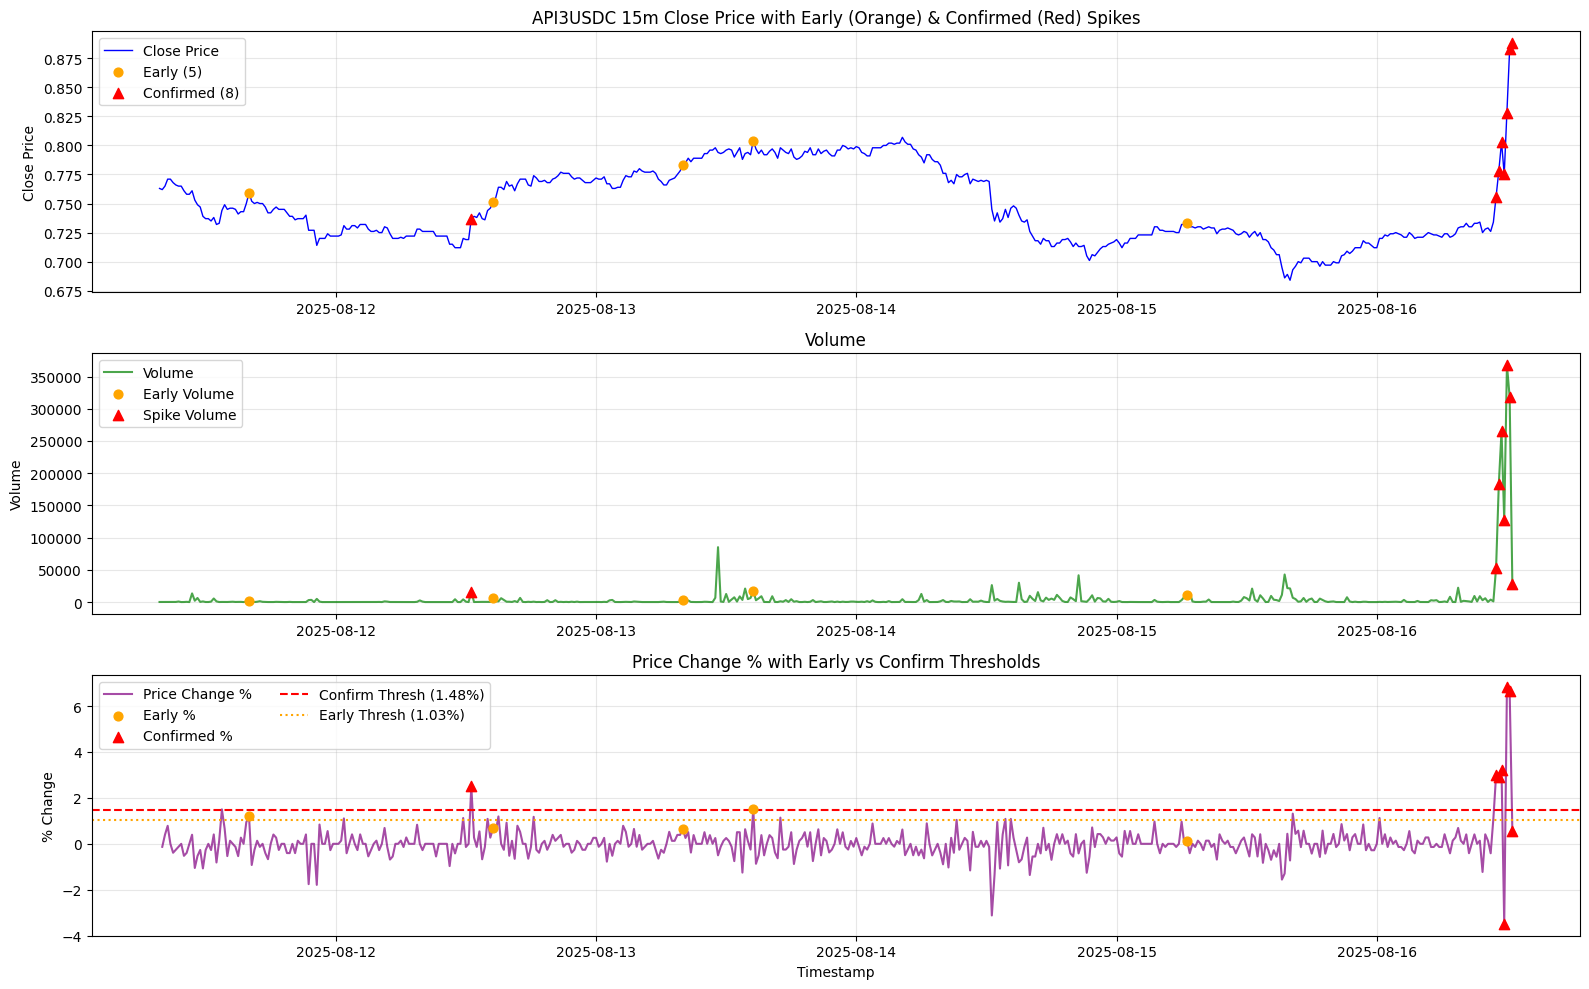

In [48]:
import matplotlib.pyplot as plt

random_symbol = symbol

df = fresh_df

price_thresh_dynamic = df["price_change"].quantile(0.95)
vol_thresh_dynamic = df["volume_ratio"].quantile(0.90)
print(f"\n🔮 Running production SpikeHunter prediction for random symbol: {random_symbol}")

# Initialize production SpikeHunter with same settings as before
prod_hunter = SpikeHunter(
    price_threshold=price_thresh_dynamic,
    volume_threshold=vol_thresh_dynamic,
    momentum_threshold=0.015,
    window=12,
    rsi_oversold=30,
)

try:
    # Fetch fresh data for the random symbol
    df_pred, summary_pred = prod_hunter.run_analysis(random_symbol, interval="15m", limit=500, verbose=True)

    # Show summary including early signals
    print("Summary:", summary_pred)

    # Show detected spikes
    spikes_pred = df_pred[df_pred["spike_signal"] == 1]
    early_pred = df_pred[df_pred["early_signal"] == 1]
    if not spikes_pred.empty or not early_pred.empty:
        print(f"\n🔥 Detected {len(spikes_pred)} confirmed spikes and {len(early_pred)} early signals for {random_symbol}:")
        print(spikes_pred[["timestamp", "close", "price_change", "volume_ratio", "spike_type", "signal_strength"]].tail(10))
    else:
        print(f"No spikes detected for {random_symbol}.")

    # --- Plot detected spikes (early vs confirmed) ---
    plt.figure(figsize=(16, 10))

    # 1. Price plot
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(df_pred["timestamp"], df_pred["close"], label="Close Price", color="blue", linewidth=1)
    early_idx = df_pred.index[df_pred["early_signal"] == 1]
    conf_idx = df_pred.index[df_pred["spike_signal"] == 1]
    if len(early_idx) > 0:
        ax1.scatter(df_pred.loc[early_idx, "timestamp"], df_pred.loc[early_idx, "close"], color="orange", label=f"Early ({len(early_idx)})", s=40, zorder=5)
    if len(conf_idx) > 0:
        ax1.scatter(df_pred.loc[conf_idx, "timestamp"], df_pred.loc[conf_idx, "close"], color="red", label=f"Confirmed ({len(conf_idx)})", s=55, zorder=6, marker="^")
    ax1.set_title(f"{random_symbol} 15m Close Price with Early (Orange) & Confirmed (Red) Spikes")
    ax1.set_ylabel("Close Price")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Volume plot
    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(df_pred["timestamp"], df_pred["volume"], label="Volume", color="green", alpha=0.7)
    if len(early_idx) > 0:
        ax2.scatter(df_pred.loc[early_idx, "timestamp"], df_pred.loc[early_idx, "volume"], color="orange", label="Early Volume", s=40, zorder=5)
    if len(conf_idx) > 0:
        ax2.scatter(df_pred.loc[conf_idx, "timestamp"], df_pred.loc[conf_idx, "volume"], color="red", label="Spike Volume", s=55, zorder=6, marker="^")
    ax2.set_title("Volume")
    ax2.set_ylabel("Volume")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Price change with thresholds
    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(df_pred["timestamp"], df_pred["price_change"] * 100, label="Price Change %", color="purple", alpha=0.7)
    if len(early_idx) > 0:
        ax3.scatter(df_pred.loc[early_idx, "timestamp"], df_pred.loc[early_idx, "price_change"] * 100, color="orange", label="Early %", s=40, zorder=5)
    if len(conf_idx) > 0:
        ax3.scatter(df_pred.loc[conf_idx, "timestamp"], df_pred.loc[conf_idx, "price_change"] * 100, color="red", label="Confirmed %", s=55, zorder=6, marker="^")
    ax3.axhline(y=price_thresh_dynamic * 100, color="red", linestyle="--", label=f"Confirm Thresh ({price_thresh_dynamic*100:.2f}%)")
    ax3.axhline(y=price_thresh_dynamic * 100 * prod_hunter.early_price_frac, color="orange", linestyle=":", label=f"Early Thresh ({price_thresh_dynamic*100*prod_hunter.early_price_frac:.2f}%)")
    ax3.set_title("Price Change % with Early vs Confirm Thresholds")
    ax3.set_xlabel("Timestamp")
    ax3.set_ylabel("% Change")
    ax3.legend(ncol=2)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"❌ Error running prediction for {random_symbol}: {e}")

In [45]:
# Evaluate early -> confirmed conversion and lead times
if 'df_pred' in globals():
    df_eval = df_pred.copy()
    if 'lead_time_candles' in df_eval.columns:
        conversions = df_eval[df_eval['lead_time_candles'].notna()]
        total_early = (df_eval['early_signal'] == 1).sum()
        converted = len(conversions)
        conversion_rate = converted / total_early if total_early else 0
        print(f"Early signals: {total_early} | Converted to confirmed: {converted} | Conversion rate: {conversion_rate:.2%}")
        if converted:
            print("Lead time (candles) stats:")
            print(conversions['lead_time_candles'].describe())
        # Distribution bucketed
        buckets = {}
        for b in [1,2,3,4,5,6]:
            buckets[b] = (conversions['lead_time_candles'] == b).sum()
        if converted:
            print("Lead time bucket counts:", buckets)
    else:
        print("lead_time_candles column missing; re-run detection cell.")
else:
    print("df_pred not found; run the prediction cell first.")

Early signals: 31 | Converted to confirmed: 5 | Conversion rate: 16.13%
Lead time (candles) stats:
count    5.00000
mean     2.20000
std      0.83666
min      1.00000
25%      2.00000
50%      2.00000
75%      3.00000
max      3.00000
Name: lead_time_candles, dtype: float64
Lead time bucket counts: {1: np.int64(1), 2: np.int64(2), 3: np.int64(2), 4: np.int64(0), 5: np.int64(0), 6: np.int64(0)}


In [49]:
# Use quantiles to set thresholds (e.g., 95th percentile for price change, 90th for volume)
price_thresh_dynamic = df_pred["price_change"].quantile(0.95)
vol_thresh_dynamic = df_pred["volume_ratio"].quantile(0.90)
print(f"Dynamic price_threshold (95th pct): {price_thresh_dynamic:.4f}")
print(f"Dynamic volume_threshold (90th pct): {vol_thresh_dynamic:.2f}")

# Re-run detection with dynamic thresholds
prod_hunter_dynamic = SpikeHunter(
    price_threshold=price_thresh_dynamic,
    volume_threshold=vol_thresh_dynamic,
    momentum_threshold=prod_hunter.momentum_threshold,
    window=prod_hunter.window,
    rsi_oversold=prod_hunter.rsi_oversold,
)
try:
    random_symbol = "API3USDC"
    df_pred_dyn, summary_pred_dyn = prod_hunter_dynamic.run_analysis(random_symbol, interval="15m", limit=500, verbose=True)
    spikes_pred_dyn = df_pred_dyn[df_pred_dyn["spike_signal"] == 1]
    early_pred_dyn = df_pred_dyn[df_pred_dyn["early_signal"] == 1]
    print(f"\n🔥 Detected {len(spikes_pred_dyn)} confirmed spikes and {len(early_pred_dyn)} early signals for {random_symbol} with dynamic thresholds.")
    print("Summary:", summary_pred_dyn)
    # Plot as before, but show both early and confirmed
    plt.figure(figsize=(16, 10))
    # Price plot
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(df_pred_dyn["timestamp"], df_pred_dyn["close"], label="Close Price", color="blue", linewidth=1)
    early_idx_dyn = df_pred_dyn.index[df_pred_dyn["early_signal"] == 1]
    conf_idx_dyn = df_pred_dyn.index[df_pred_dyn["spike_signal"] == 1]
    if len(early_idx_dyn) > 0:
        ax1.scatter(df_pred_dyn.loc[early_idx_dyn, "timestamp"], df_pred_dyn.loc[early_idx_dyn, "close"], color="orange", label=f"Early ({len(early_idx_dyn)})", s=40, zorder=5)
    if len(conf_idx_dyn) > 0:
        ax1.scatter(df_pred_dyn.loc[conf_idx_dyn, "timestamp"], df_pred_dyn.loc[conf_idx_dyn, "close"], color="red", label=f"Confirmed ({len(conf_idx_dyn)})", s=55, zorder=6, marker="^")
    ax1.set_title(f"{random_symbol} 15m Close Price with Early (Orange) & Confirmed (Red) Spikes")
    ax1.set_ylabel("Close Price")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    # Volume plot
    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(df_pred_dyn["timestamp"], df_pred_dyn["volume"], label="Volume", color="green", alpha=0.7)
    if len(early_idx_dyn) > 0:
        ax2.scatter(df_pred_dyn.loc[early_idx_dyn, "timestamp"], df_pred_dyn.loc[early_idx_dyn, "volume"], color="orange", label="Early Volume", s=40, zorder=5)
    if len(conf_idx_dyn) > 0:
        ax2.scatter(df_pred_dyn.loc[conf_idx_dyn, "timestamp"], df_pred_dyn.loc[conf_idx_dyn, "volume"], color="red", label="Spike Volume", s=55, zorder=6, marker="^")
    ax2.set_title("Volume")
    ax2.set_ylabel("Volume")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    # Price change plot
    ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    ax3.plot(df_pred_dyn["timestamp"], df_pred_dyn["price_change"] * 100, label="Price Change %", color="purple", alpha=0.7)
    if len(early_idx_dyn) > 0:
        ax3.scatter(df_pred_dyn.loc[early_idx_dyn, "timestamp"], df_pred_dyn.loc[early_idx_dyn, "price_change"] * 100, color="orange", label="Early %", s=40, zorder=5)
    if len(conf_idx_dyn) > 0:
        ax3.scatter(df_pred_dyn.loc[conf_idx_dyn, "timestamp"], df_pred_dyn.loc[conf_idx_dyn, "price_change"] * 100, color="red", label="Confirmed %", s=55, zorder=6, marker="^")
    ax3.axhline(y=price_thresh_dynamic * 100, color="red", linestyle="--", label=f"Confirm Thresh ({price_thresh_dynamic*100:.2f}%)")
    ax3.axhline(y=price_thresh_dynamic * 100 * prod_hunter_dynamic.early_price_frac, color="orange", linestyle=":", label=f"Early Thresh ({price_thresh_dynamic*100*prod_hunter_dynamic.early_price_frac:.2f}%)")
    ax3.set_title("Price Change % with Early vs Confirm Thresholds")
    ax3.set_xlabel("Timestamp")
    ax3.set_ylabel("% Change")
    ax3.legend(ncol=2)
    ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # Show lead time stats
    if 'lead_time_candles' in df_pred_dyn.columns:
        conversions = df_pred_dyn[df_pred_dyn['lead_time_candles'].notna()]
        total_early = (df_pred_dyn['early_signal'] == 1).sum()
        converted = len(conversions)
        conversion_rate = converted / total_early if total_early else 0
        print(f"Early signals: {total_early} | Converted to confirmed: {converted} | Conversion rate: {conversion_rate:.2%}")
        if converted:
            print("Lead time (candles) stats:")
            print(conversions['lead_time_candles'].describe())
except Exception as e:
    print(f"❌ Error running dynamic threshold prediction for {random_symbol}: {e}")

Dynamic price_threshold (95th pct): 0.0092
Dynamic volume_threshold (90th pct): 3.23
❌ Error running dynamic threshold prediction for API3USDC: Failed to fetch market data for API3USDC: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/klines?symbol=API3USDC&interval=15m&limit=500 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x11991cc50>: Failed to resolve 'api.binance.com' ([Errno 8] nodename nor servname provided, or not known)"))


In [51]:
# === Analyze why detection rate is low for the random symbol ===
if not active_symbols:
    print("No active symbols available.")
else:
    print(f"\n--- Detection Rate Analysis for {random_symbol} ---")
    print(f"Total candles: {len(df_pred)}")
    print(f"Confirmed spikes detected: {len(spikes_pred)}")
    print(f"Early signals detected: {len(df_pred[df_pred['early_signal'] == 1])}")
    if len(df_pred) > 0:
        print(f"Confirmed detection rate: {len(spikes_pred)/len(df_pred):.4f}")
        print(f"Early signal rate: {len(df_pred[df_pred['early_signal'] == 1])/len(df_pred):.4f}")
    # Show price change and volume ratio statistics
    print("\nPrice change statistics:")
    print(df_pred["price_change"].describe())
    print("\nVolume ratio statistics:")
    print(df_pred["volume_ratio"].describe())
    # Show how many candles exceed the thresholds
    price_thresh = prod_hunter.price_threshold
    vol_thresh = prod_hunter.volume_threshold
    price_spikes = df_pred[df_pred["price_change"] > price_thresh]
    vol_spikes = df_pred[df_pred["volume_ratio"] > vol_thresh]
    both_spikes = df_pred[(df_pred["price_change"] > price_thresh) & (df_pred["volume_ratio"] > vol_thresh)]
    print(f"\nCandles with price_change > {price_thresh:.3f}: {len(price_spikes)}")
    print(f"Candles with volume_ratio > {vol_thresh:.2f}: {len(vol_spikes)}")
    print(f"Candles with BOTH > thresholds: {len(both_spikes)}")
    # Show some of the largest price changes and volume ratios
    print("\nTop 5 price changes:")
    print(df_pred.nlargest(5, "price_change")[["timestamp", "close", "price_change", "volume_ratio"]])
    print("\nTop 5 volume ratios:")
    print(df_pred.nlargest(5, "volume_ratio")[["timestamp", "close", "price_change", "volume_ratio"]])
    # Check if the symbol is generally low volatility or low volume
    print("\nMean close price:", df_pred["close"].mean())
    print("Mean volume:", df_pred["volume"].mean())
    print("Std price_change:", df_pred["price_change"].std())
    print("Std volume_ratio:", df_pred["volume_ratio"].std())
    # Early to confirmed conversion
    if 'lead_time_candles' in df_pred.columns:
        conversions = df_pred[df_pred['lead_time_candles'].notna()]
        total_early = (df_pred['early_signal'] == 1).sum()
        converted = len(conversions)
        conversion_rate = converted / total_early if total_early else 0
        print(f"\nEarly signals: {total_early} | Converted to confirmed: {converted} | Conversion rate: {conversion_rate:.2%}")
        if converted:
            print("Lead time (candles) stats:")
            print(conversions['lead_time_candles'].describe())
    print("\nIf very few candles exceed the thresholds, consider lowering price_threshold or volume_threshold, or check if the symbol is inactive/illiquid.")


--- Detection Rate Analysis for API3USDC ---
Total candles: 500
Confirmed spikes detected: 8
Early signals detected: 5
Confirmed detection rate: 0.0160
Early signal rate: 0.0100

Price change statistics:
count    499.000000
mean       0.000329
std        0.007147
min       -0.034869
25%       -0.002586
50%        0.000000
75%        0.002596
max        0.068387
Name: price_change, dtype: float64

Volume ratio statistics:
count    500.000000
mean       1.109635
std        1.955943
min        0.000000
25%        0.055880
50%        0.310534
75%        1.119453
max       11.561737
Name: volume_ratio, dtype: float64

Candles with price_change > 0.015: 8
Candles with volume_ratio > 3.40: 48
Candles with BOTH > thresholds: 5

Top 5 price changes:
              timestamp  close  price_change  volume_ratio
497 2025-08-16 12:00:00  0.828      0.068387      4.324874
498 2025-08-16 12:15:00  0.883      0.066425      2.853975
495 2025-08-16 11:30:00  0.803      0.032134      5.950848
493 2025-08-